# NLP Group 08 Project

# NLP-Based Customer Support Ticket Classification System

### Notebook 1:  Data Collection and Exploration

**Course:** 7500 - Natural Language Processing  
**Group:** 08

---

## Objective

The purpose of this notebook is to perform an initial exploration of the customer support ticket dataset. This includes loading the dataset, examining its structure, identifying the available features, checking for missing values, and exploring the distribution of ticket categories. The insights gained from this analysis will guide the preprocessing and model development stages of the project.

## Pipeline Overview

This notebook completes the Data Collection phase of the NLP pipeline by:

- Importing the required libraries.
- Loading the customer support ticket dataset.
- Examining the dataset structure.
- Checking data types and missing values.
- Exploring ticket categories and priorities.
- Identifying the input feature and target variable for the classification model.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Data

In [2]:
def load_dataset(filepath):
    df = pd.read_parquet(filepath)
    
    # View dataset
    # df_sample = df.head()
    return df

In [3]:
# Data  set overview
def dataset_overview(path):
    df_rows = print(f'Rows: {path.shape[0]}')
    df_columns = print(f'Columns: {path.shape[1]}')
    column_name= print(f'\n Column Names: {path.columns.tolist()}')
    df_info= print(f'\n Dataset info: {path.info()}')
    df_nulls= print(f'\n Missing Values: {path.isnull().sum()}')
    return df_rows, df_columns, column_name, df_info, df_nulls      

In [4]:
# Data collection
FILEPATH= "../data/nlp_dataset.parquet"

df = load_dataset(FILEPATH)

dataset_overview(df)


Rows: 8469
Columns: 6

 Column Names: ['Customer Email', 'Product Purchased', 'Ticket Type', 'Ticket Subject', 'Combined Text', 'Ticket Priority']
<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Customer Email     8469 non-null   str  
 1   Product Purchased  8469 non-null   str  
 2   Ticket Type        8469 non-null   str  
 3   Ticket Subject     8469 non-null   str  
 4   Combined Text      8469 non-null   str  
 5   Ticket Priority    8469 non-null   str  
dtypes: str(6)
memory usage: 3.5 MB

 Dataset info: None

 Missing Values: Customer Email       0
Product Purchased    0
Ticket Type          0
Ticket Subject       0
Combined Text        0
Ticket Priority      0
dtype: int64


(None, None, None, None, None)

## Preliminary EDA

In [5]:
def df_classes(path):
    # Unique classes
    ticket_type= path['Ticket Type'].unique()
    df_ticket_type= print(f'\n Unique Ticket Types: {ticket_type}')
    
    # Count of Classes
    num_classes = path['Ticket Type'].nunique()
    df_num_classes = print(f'\n Number of Classes: {num_classes}')
    
    return df_ticket_type, df_num_classes

df_classes(df)


 Unique Ticket Types: <ArrowStringArray>
[     'technical issue',      'billing inquiry', 'cancellation request',
      'product inquiry',       'refund request']
Length: 5, dtype: str

 Number of Classes: 5


(None, None)

### Text distribution

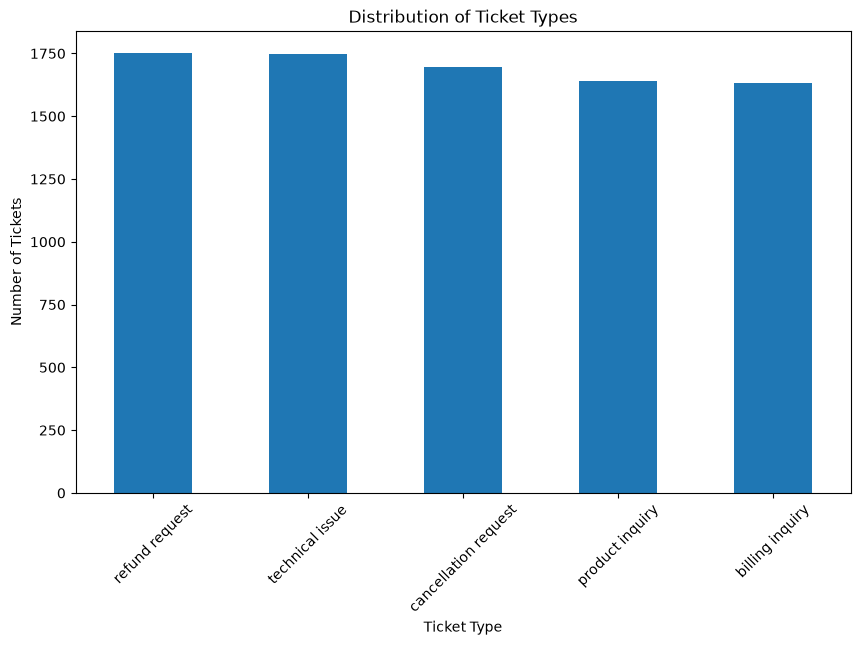

<Axes: title={'center': 'Distribution of Ticket Types'}, xlabel='Ticket Type', ylabel='Number of Tickets'>

In [6]:
def ticket_distribution(path):
    # Figure size
    plt.figure(figsize=(10,6))
    
    ticket_dist= path['Ticket Type'].value_counts().plot(kind= 'bar')
    
    plt.title("Distribution of Ticket Types")
    plt.xlabel("Ticket Type")
    plt.ylabel("Number of Tickets")
    plt.xticks(rotation=45)

    plt.show()
    
    return ticket_dist

ticket_distribution(df)

### Ticket Priority

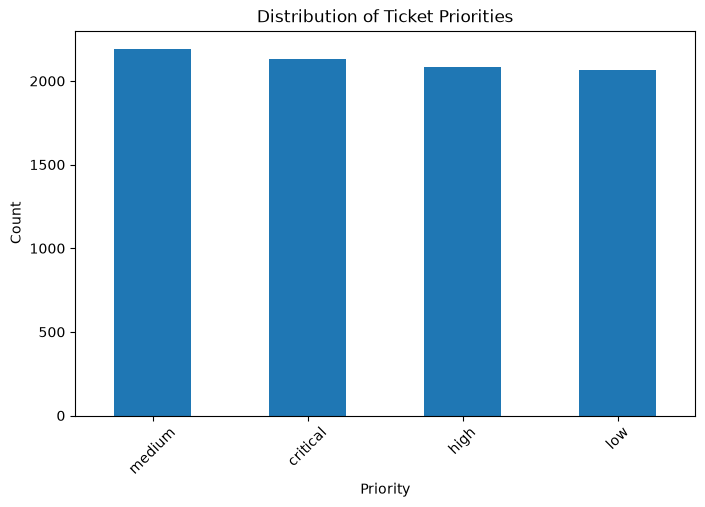

<Axes: title={'center': 'Distribution of Ticket Priorities'}, xlabel='Priority', ylabel='Count'>

In [7]:
def ticket_priority(path):
    plt.figure(figsize=(8,5))

    df_priority= path["Ticket Priority"].value_counts().plot(kind="bar")

    plt.title("Distribution of Ticket Priorities")
    plt.xlabel("Priority")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()
    
    return df_priority

ticket_priority(df)


### Text Distribution

0    294
1    285
2    287
3    305
4    355
Name: Text Length, dtype: int64
count    8469.000000
mean      306.791593
std        45.183917
min       154.000000
25%       287.000000
50%       314.000000
75%       336.000000
max       429.000000
Name: Text Length, dtype: float64


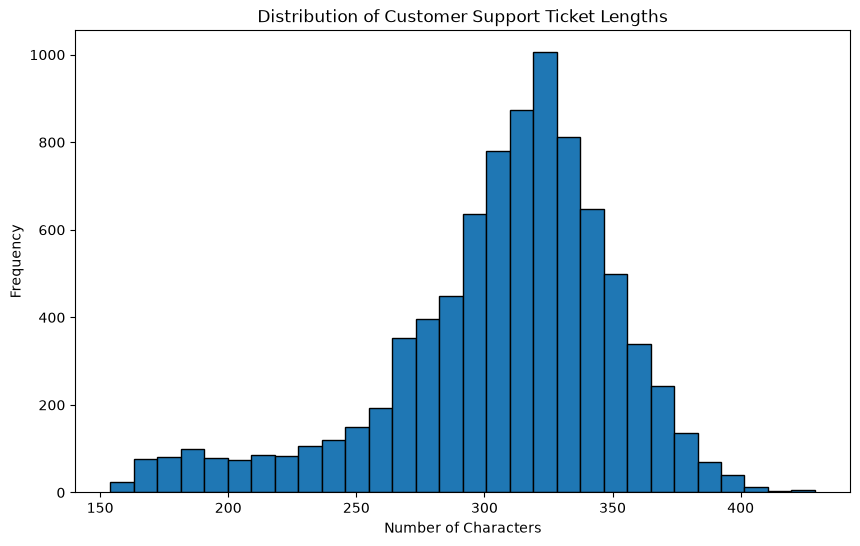

<Axes: title={'center': 'Distribution of Customer Support Ticket Lengths'}, xlabel='Number of Characters', ylabel='Frequency'>

In [8]:
def text_distribution(path):
    # Make sure Text Length exists and is numeric
    path["Text Length"] = df["Combined Text"].astype(str).apply(len)

    print(path["Text Length"].head())
    print(path["Text Length"].describe())

    # Plot
    df_text_hist= path["Text Length"].plot(kind="hist", bins=30, figsize=(10,6), edgecolor="black")

    plt.title("Distribution of Customer Support Ticket Lengths")
    plt.xlabel("Number of Characters")
    plt.ylabel("Frequency")
    plt.show()
    
    return df_text_hist

text_distribution(df)

## Observations

- The dataset contains 8,469 customer support tickets.
- There are six features describing each support request.
- No missing values were identified.
- Dataset features are balanced.
- The primary text feature is **Combined Text**.
- The target variable for classification is **Ticket Type**.
- The dataset is ready for preprocessing